<a href="https://colab.research.google.com/github/karinenoronha/People-Analytics/blob/main/People_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **People Analytics**

**Key questions:**

What is the turnover rate?

Which departments have the highest attrition?


Do lower-paid employees leave more often?


Does tenure influence employee turnover?


Does job satisfaction impact retention?

In [2]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [5]:
pd.isnull(df).sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [6]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [7]:
# create a numerical target variable to attrition to yes =1, no = 0

df['Attrition_flag'] = df['Attrition'].map({'Yes':1,'No':0})

In [8]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition_flag
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,80,0,8,0,1,6,4,0,5,1
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,80,1,10,3,3,10,7,1,7,0
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,80,0,7,3,3,0,0,0,0,1
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,80,0,8,3,3,8,7,3,0,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,80,1,6,3,3,2,2,2,2,0


In [9]:
#Standardize columns

df.columns = df.columns.str.lower()

In [10]:
turnover_rate = df["attrition_flag"].mean()
turnover_rate

np.float64(0.16122448979591836)

It means the turnover rate is 16,12%.

In [11]:
import sqlite3

In [12]:

conn = sqlite3.connect("hr_database.db")

df.to_sql("employees", conn, if_exists="replace", index=False)

1470

In [13]:
df.to_sql("employees", conn, if_exists="replace", index=False)
df.to_sql("salaries", conn, if_exists="replace", index=False)
df.to_sql("engagement", conn, if_exists="replace", index=False)

1470

In [14]:
%whos

Variable        Type          Data/Info
---------------------------------------
conn            Connection    <sqlite3.Connection object at 0x7ef518085210>
df              DataFrame           age attrition     b<...>n[1470 rows x 36 columns]
matplotlib      module        <module 'matplotlib' from<...>/matplotlib/__init__.py'>
np              module        <module 'numpy' from '/us<...>kages/numpy/__init__.py'>
pd              module        <module 'pandas' from '/u<...>ages/pandas/__init__.py'>
plt             module        <module 'matplotlib.pyplo<...>es/matplotlib/pyplot.py'>
sns             module        <module 'seaborn' from '/<...>ges/seaborn/__init__.py'>
sqlite3         module        <module 'sqlite3' from '/<...>.12/sqlite3/__init__.py'>
turnover_rate   float64       0.16122448979591836


In [15]:
query = """
SELECT AVG(attrition_flag) as turnover_rate
FROM employees;
"""
query_result = pd.read_sql_query(query, conn)
query_result

,turnover_rate
0,0.161224


In [16]:
query = """
SELECT department, AVG(attrition_flag) as turnover_rate
FROM employees
GROUP BY department
ORDER BY turnover_rate DESC;
"""
query_result = pd.read_sql_query(query, conn)
query_result

,department,turnover_rate
0,Sales,0.206278
1,Human Resources,0.190476
2,Research & Development,0.138398


The overall turnover rate is 16.22%. Sales shows the highest attrition rate (20.62%), followed by HR (19.04%), while Research & Development has the lowest among the three (13.83%).

In [17]:
#Average salary of employees who left vs. those who stayed

query = """
SELECT  e.attrition_flag, AVG(s.monthlyincome) as avg_salary
FROM employees e
JOIN salaries s ON e.employeenumber = s.employeenumber
GROUP BY e.attrition_flag;
"""

query_result = pd.read_sql_query(query, conn)
query_result

,attrition_flag,avg_salary
0,0,6832.739659
1,1,4787.092827


In [18]:
# Job satisfaction vs. turnover

query= """
SELECT
    attrition_flag,
    AVG(JobSatisfaction) AS avg_satisfaction
FROM employees
GROUP BY attrition_flag;"""

query_result = pd.read_sql_query(query, conn)
query_result

,attrition_flag,avg_satisfaction
0,0,2.778589
1,1,2.468354


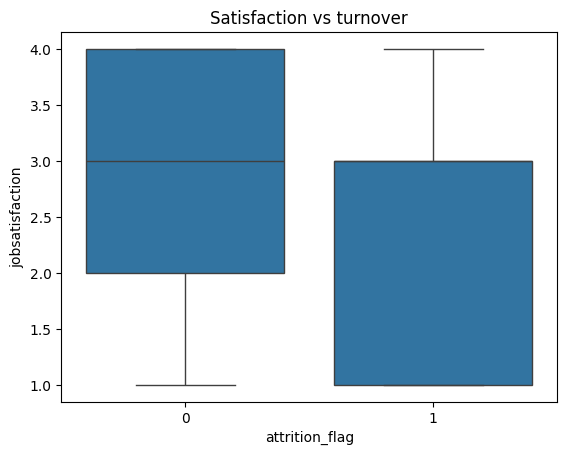

In [44]:
sns.boxplot(x='attrition_flag', y='jobsatisfaction', data=df)
plt.title('Satisfaction vs turnover')
plt.show()

In [19]:
# jobrole vs.	turnover_rate

query = """
SELECT e.jobrole, AVG(e.attrition_flag) as turnover_rate
FROM employees e
JOIN engagement en ON e.employeenumber = en.employeenumber
GROUP BY e.jobrole
ORDER BY turnover_rate DESC;
"""

query_result = pd.read_sql_query(query, conn)
query_result

,jobrole,turnover_rate
0,Sales Representative,0.397590
1,Laboratory Technician,0.239382
2,Human Resources,0.230769
3,Sales Executive,0.174847
4,Research Scientist,0.160959
5,Manufacturing Director,0.068966
6,Healthcare Representative,0.068702
7,Manager,0.049020
8,Research Director,0.025000


It can be observed that the turnover rate among sales representatives is higher, likely due to factors such as salary levels and performance pressure.


In [20]:
#Overtime vs tornover rate

query = """
SELECT overtime, AVG(attrition_flag) as turnover_rate
FROM employees
GROUP BY overtime;
"""

query_result = pd.read_sql_query(query, conn)
query_result


,overtime,turnover_rate
0,No,0.104364
1,Yes,0.305288


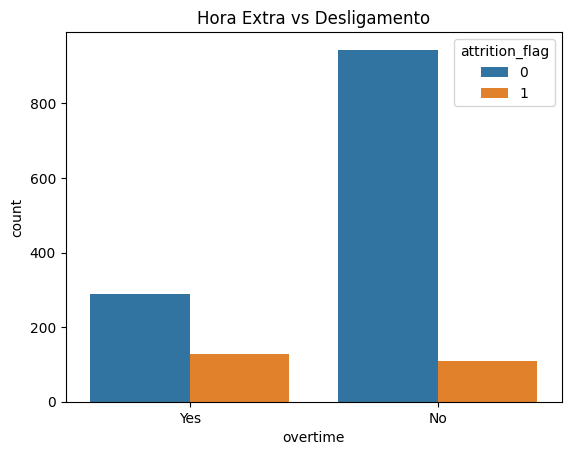

In [37]:
sns.countplot(x='overtime', hue='attrition_flag', data=df)
plt.title('Hora Extra vs Desligamento')
plt.show()

Employees who work overtime tend to have a higher turnover rate compared to those who do not.

In [21]:
# Undestanding people "risk"

query = """
SELECT *
FROM employees e
WHERE MonthlyIncome < (
          SELECT AVG(MonthlyIncome)
          FROM employees)
AND JobSatisfaction <3;
"""


query_result = pd.read_sql_query(query, conn)
query_result

,age,attrition,businesstravel,dailyrate,department,distancefromhome,education,educationfield,employeecount,employeenumber,...,standardhours,stockoptionlevel,totalworkingyears,trainingtimeslastyear,worklifebalance,yearsatcompany,yearsincurrentrole,yearssincelastpromotion,yearswithcurrmanager,attrition_flag
0,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,80,1,10,3,3,10,7,1,7,0
1,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,80,1,6,3,3,2,2,2,2,0
2,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,80,3,12,3,2,1,0,0,0,0
3,35,No,Travel_Rarely,809,Research & Development,16,3,Medical,1,14,...,80,1,6,5,3,5,4,0,3,0
4,32,No,Travel_Rarely,334,Research & Development,5,2,Life Sciences,1,21,...,80,2,7,5,2,6,2,0,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,32,No,Travel_Rarely,529,Research & Development,2,3,Technical Degree,1,2038,...,80,0,4,4,3,4,2,1,2,0
370,29,No,Travel_Rarely,1378,Research & Development,13,2,Other,1,2053,...,80,1,10,2,3,4,3,0,3,0
371,29,No,Travel_Rarely,468,Research & Development,28,4,Medical,1,2054,...,80,0,5,3,1,5,4,0,4,0
372,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,80,1,6,0,3,6,2,0,3,0


In [25]:
# Department with the highest risk of employee turnover.

query = """
SELECT  department, COUNT(*) AS total_employees,AVG(attrition_flag) AS turnover_rate
FROM employees
GROUP BY department
ORDER BY turnover_rate DESC;
"""


query_result = pd.read_sql_query(query, conn)
query_result

,department,total_employees,turnover_rate
0,Sales,446,0.206278
1,Human Resources,63,0.190476
2,Research & Development,961,0.138398


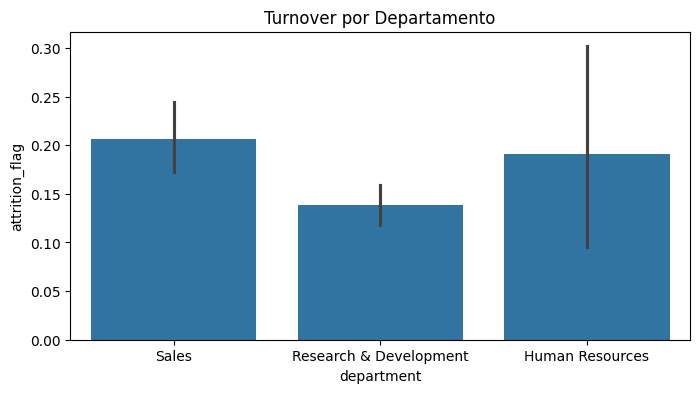

In [40]:
plt.figure(figsize=(8,4))
sns.barplot(x='department', y=df['attrition_flag'], data=df)
plt.title('Turnover por Departamento')
plt.show()

 Insights

1. Departments with higher turnover rates tend to have average salaries below the company average.



2. Employees with low job satisfaction are approximately twice as likely to leave the company.


3. vertime work is strongly associated with increased employee turnover.